# Aviation Policy Tweets EDA

This notebook is a project-specific exploratory analysis of the provided `tweets.csv` file, written to align with the final-project proposal and the follow-up clarification notes in `context.docx`.

The notebook treats the data as a descriptive case study of public discourse around aviation safety, FAA staffing, delays, and oversight. It is intentionally scoped as EDA rather than a full modeling pipeline.

Project folder referenced in this notebook:
- `E:\Course_Work_CMU\Unstructured_DS\Final_Project`


## Framing From The Proposal And Context

The proposal argues that public-facing social media posts can help surface recurring passenger harms and operational concerns relevant to aviation policy. The follow-up email context narrows that claim in a useful way: rather than treating tweets as direct proof for regulation, the project should use them as an exploratory signal of what themes dominate the public conversation.

This notebook follows that clarified framing by focusing on four EDA questions:

- What does the provided tweet corpus actually contain, and how much cleaning is needed?
- When does discussion spike over time, and how concentrated is the conversation across accounts?
- Which policy-relevant themes appear most often in the text?
- How do engagement and language patterns differ across those themes?

One important note from the audit below: the provided CSV is not the original 2015 Kaggle airline-sentiment dataset described in the initial proposal. It is a newer tweet scrape with tweet-level metadata such as `createdAt`, `viewCount`, and `isReply`, so the notebook is tailored to the actual file you supplied.


In [1]:
from pathlib import Path
import re
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

plt.style.use("default")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.18
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

NAVY = "#1D3557"
TEAL = "#2A9D8F"
GOLD = "#E9C46A"
ORANGE = "#F4A261"
RED = "#E76F51"
PURPLE = "#6D597A"
SLATE = "#6C757D"

THEME_PATTERNS = {
    "air_traffic_control": r"\bair traffic control\b|\batc\b|\bcontroller(?:s)?\b|\btower\b",
    "staffing_hiring": r"\bstaff(?:ing|ed)?\b|\bshortage(?:s)?\b|\bhiring\b|\brecruit(?:ing|ment)?\b|\bpipeline\b",
    "safety_incidents": r"\bsafety\b|\bcrash\b|\bcollision\b|\bincident\b|\btragedy\b|\brisk\b|\brunway\b",
    "delays_disruptions": r"\bdelay(?:s|ed)?\b|\bground stop\b|\bground delay\b|\bcancel(?:lation|led|ed)?\b|\bdisruption(?:s)?\b|\bflight-cut(?:s)?\b",
    "faa_policy_oversight": r"\bfaa\b|federal aviation administration|\boversight\b|\breform\b|\bregulation(?:s)?\b|\bpolicy\b|\bmandate(?:s)?\b",
    "modernization_technology": r"\bmoderni(?:ze|zation|sation|sed|zed)\b|\boutdated\b|\bupgrade(?:s|d)?\b|\btechnology\b|\bsystem(?:s)?\b|\bdata\b|\bradar\b",
}

THEME_LABELS = {
    "theme_air_traffic_control": "Air traffic control",
    "theme_staffing_hiring": "Staffing and hiring",
    "theme_safety_incidents": "Safety and incidents",
    "theme_delays_disruptions": "Delays and disruptions",
    "theme_faa_policy_oversight": "FAA policy and oversight",
    "theme_modernization_technology": "Modernization and technology",
}

STOPWORDS = {
    "the", "and", "for", "that", "this", "with", "from", "have", "has", "had", "are", "was",
    "were", "will", "would", "could", "should", "into", "about", "there", "their", "them",
    "they", "our", "out", "all", "you", "your", "just", "not", "but", "can", "more", "than",
    "its", "it's", "after", "before", "over", "under", "while", "because", "also", "still",
    "today", "here", "when", "what", "why", "how", "who", "where", "been", "being", "through",
    "amp", "via", "rt", "http", "https", "www", "com", "did", "does", "doing", "done", "say",
    "says", "said", "get", "gets", "got", "make", "made", "want", "wants", "like", "need",
    "needs", "time", "year", "years", "day", "days", "month", "months", "week", "weeks",
    "now", "new", "old", "one", "two", "three", "first", "second", "last", "next", "much",
    "many", "may", "might", "must", "very", "every", "each", "same", "other", "another", "only",
    "around", "across", "among", "against", "between", "within", "without", "during", "since",
    "until", "onto", "off", "back", "even", "most", "least", "few", "lot", "lots", "per",
}


def annotate_bars(ax, fmt="{:,.0f}", y_pad_ratio=0.02):
    y_max = ax.get_ylim()[1]
    for patch in ax.patches:
        height = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + y_max * y_pad_ratio,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=9,
        )


def parse_created_at(series: pd.Series) -> pd.Series:
    parsed = pd.to_datetime(
        series,
        format="%a %b %d %H:%M:%S %z %Y",
        errors="coerce",
        utc=True,
    )
    if parsed.isna().any():
        parsed = pd.to_datetime(series, errors="coerce", utc=True)
    return parsed


def clean_text(text: str) -> str:
    text = "" if pd.isna(text) else str(text)
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"[^A-Za-z#\s]", " ", text)
    text = re.sub(r"\s+", " ", text.lower()).strip()
    return text


def extract_handle(url: str) -> str:
    if pd.isna(url):
        return "unknown"
    match = re.search(r"x\.com/([^/]+)/status", str(url))
    return match.group(1) if match else "unknown"


def top_ngrams(texts, ngram=1, top_n=15, extra_stopwords=None):
    counter = Counter()
    blocked = set(STOPWORDS)
    if extra_stopwords:
        blocked.update(extra_stopwords)

    for text in texts:
        tokens = [
            token
            for token in clean_text(text).split()
            if len(token) > 2 and token not in blocked and not token.startswith("#")
        ]
        if ngram == 1:
            counter.update(tokens)
        else:
            counter.update(zip(*(tokens[i:] for i in range(ngram))))

    rows = []
    for term, count in counter.most_common(top_n):
        if isinstance(term, tuple):
            term = " ".join(term)
        rows.append((term, count))
    return rows


def prepare_frame(frame: pd.DataFrame) -> pd.DataFrame:
    df = frame.copy()

    numeric_cols = [
        "retweetCount",
        "replyCount",
        "likeCount",
        "quoteCount",
        "viewCount",
        "bookmarkCount",
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

    for col in ["isReply", "isQuote", "isPinned"]:
        df[col] = df[col].fillna(False).astype(bool)

    df["created_at"] = parse_created_at(df["createdAt"])
    df["created_at_est"] = df["created_at"].dt.tz_convert("America/New_York")
    df["date"] = df["created_at_est"].dt.date
    df["month"] = df["created_at_est"].dt.tz_localize(None).dt.to_period("M")
    df["handle"] = df["url"].map(extract_handle)
    df["text_clean"] = df["text"].map(clean_text)
    df["char_count"] = df["text"].fillna("").str.len()
    df["word_count"] = df["text"].fillna("").str.split().str.len()
    df["mention_count"] = df["text"].fillna("").str.count(r"@\w+")
    df["hashtag_count"] = df["text"].fillna("").str.count(r"#\w+")
    df["url_count"] = df["text"].fillna("").str.count(r"http\S+")
    df["exclamation_count"] = df["text"].fillna("").str.count("!")
    df["question_count"] = df["text"].fillna("").str.count(r"\?")
    df["engagement"] = (
        df["retweetCount"]
        + df["replyCount"]
        + df["likeCount"]
        + df["quoteCount"]
        + df["bookmarkCount"]
    )
    df["log_views"] = np.log1p(df["viewCount"])
    df["log_engagement"] = np.log1p(df["engagement"])

    def uppercase_ratio(text: str) -> float:
        letters = re.findall(r"[A-Za-z]", "" if pd.isna(text) else str(text))
        if not letters:
            return np.nan
        uppercase = sum(letter.isupper() for letter in letters)
        return uppercase / len(letters)

    df["uppercase_ratio"] = df["text"].map(uppercase_ratio)

    for name, pattern in THEME_PATTERNS.items():
        df[f"theme_{name}"] = df["text"].str.contains(pattern, case=False, regex=True, na=False)

    df["post_type"] = np.select(
        [df["isReply"], df["isQuote"]],
        ["Reply", "Quote tweet"],
        default="Original / reposted post",
    )

    return df.sort_values("created_at").reset_index(drop=True)


## Load The Files

The notebook reads the CSV directly from your project folder. It also confirms that the proposal and context documents exist, since this analysis is structured around those materials.


In [2]:
PROJECT_DIR = Path(r"E:\Course_Work_CMU\Unstructured_DS\Final_Project")
DATA_PATH = PROJECT_DIR / "tweets.csv"
PROPOSAL_PATH = PROJECT_DIR / "Archie_Atikemah_Huynh_Wang_UDA_Final_Project_Proposal.docx"
CONTEXT_PATH = PROJECT_DIR / "context.docx"

for path in [DATA_PATH, PROPOSAL_PATH, CONTEXT_PATH]:
    print(f"{path.name} exists: {path.exists()}")

raw = pd.read_csv(DATA_PATH)
tweets = prepare_frame(raw)
tweets_dedup = prepare_frame(raw.drop_duplicates(subset="id").reset_index(drop=True))

print("Raw shape:", raw.shape)
print("Deduplicated shape:", tweets_dedup.shape)
display(tweets_dedup.head(3))


tweets.csv exists: True
Archie_Atikemah_Huynh_Wang_UDA_Final_Project_Proposal.docx exists: True
context.docx exists: True
Raw shape: (4372, 16)
Deduplicated shape: (2344, 40)


,id,url,text,createdAt,author.profilePicture,retweetCount,replyCount,likeCount,quoteCount,viewCount,bookmarkCount,source,lang,isReply,isQuote,isPinned,created_at,created_at_est,date,month,handle,text_clean,char_count,word_count,mention_count,hashtag_count,url_count,exclamation_count,question_count,engagement,log_views,log_engagement,uppercase_ratio,theme_air_traffic_control,theme_staffing_hiring,theme_safety_incidents,theme_delays_disruptions,theme_faa_policy_oversight,theme_modernization_technology,post_type
0,1613240491931230208,https://x.com/nevermore_007/status/1613240491931230208,Flight cancellations and delays pile up after an FAA safety system outage\n\nhttps://t.co/N4ol3GxEEC,Wed Jan 11 18:24:40 +0000 2023,https://pbs.twimg.com/profile_images/1266267087976054784/rFfHLkLB_normal.jpg,0,0,0,0,74,0,NaN,en,False,False,False,2023-01-11 18:24:40+00:00,2023-01-11 13:24:40-05:00,2023-01-11,2023-01,nevermore_007,flight cancellations and delays pile up after an faa safety system outage,98,13,0,0,1,0,0,0,4.317,0.000,0.115,False,False,True,True,True,True,Original / reposted post
1,1613578883948843032,https://x.com/adndotcom/status/1613578883948843032,"Delays and cancellations among flights across the U.S. were minimal Thursday, a day after a system that offers safety information to pilots failed, grounding U.S. air traffic and leading to thousands of stranded travelers.\nhttps://t.co...",Thu Jan 12 16:49:19 +0000 2023,https://pbs.twimg.com/profile_images/932121310108442624/NY7s0rqO_normal.jpg,1,0,3,0,1097,0,NaN,en,False,False,False,2023-01-12 16:49:19+00:00,2023-01-12 11:49:19-05:00,2023-01-12,2023-01,adndotcom,delays and cancellations among flights across the u s were minimal thursday a day after a system that offers safety information to pilots failed grounding u s air traffic and leading to thousands of stranded travelers,246,35,0,0,1,0,0,4,7.001,1.609,0.055,False,False,True,True,False,True,Original / reposted post
2,1613581607608225807,https://x.com/wjxt4/status/1613581607608225807,"The FAA continues its investigation to determine who and what is responsible for the corrupted file that caused a flight safety system outage Wednesday. Meanwhile, there were more delays Thursday and travelers are fed up. https://t.co/J...",Thu Jan 12 17:00:08 +0000 2023,https://pbs.twimg.com/profile_images/1608580808058589186/_5ROenBl_normal.png,0,0,3,0,1311,0,NaN,en,False,False,False,2023-01-12 17:00:08+00:00,2023-01-12 12:00:08-05:00,2023-01-12,2023-01,wjxt4,the faa continues its investigation to determine who and what is responsible for the corrupted file that caused a flight safety system outage wednesday meanwhile there were more delays thursday and travelers are fed up,245,36,0,0,1,0,0,3,7.179,1.386,0.054,False,False,True,True,True,True,Original / reposted post


## Data Audit And Cleaning

Because the email context describes a scrape-based dataset, the first step is to verify what actually landed in the file. In particular, we want to confirm time coverage, duplicate intensity, missingness, and basic post structure before making substantive claims.


In [3]:
audit = pd.DataFrame(
    {
        "metric": [
            "raw rows",
            "raw columns",
            "unique tweet ids",
            "unique tweet texts",
            "duplicate rows removed by id",
            "duplicate share of raw rows (%)",
            "cleaned date start (ET)",
            "cleaned date end (ET)",
            "English-language share (%)",
            "reply share in cleaned data (%)",
            "quote-tweet share in cleaned data (%)",
        ],
        "value": [
            len(tweets),
            tweets.shape[1],
            tweets["id"].nunique(),
            tweets["text"].nunique(),
            len(tweets) - len(tweets_dedup),
            100 * (1 - len(tweets_dedup) / len(tweets)),
            tweets_dedup["created_at_est"].min(),
            tweets_dedup["created_at_est"].max(),
            100 * tweets_dedup["lang"].eq("en").mean(),
            100 * tweets_dedup["isReply"].mean(),
            100 * tweets_dedup["isQuote"].mean(),
        ],
    }
)

missing_summary = (
    pd.DataFrame(
        {
            "dtype": tweets.dtypes.astype(str),
            "missing_count": tweets.isna().sum(),
            "missing_pct": tweets.isna().mean() * 100,
        }
    )
    .sort_values(["missing_count", "dtype"], ascending=[False, True])
)

duplicate_examples = (
    tweets[tweets.duplicated("id", keep=False)]
    .groupby("id")
    .agg(
        duplicate_rows=("id", "size"),
        handle=("handle", "first"),
        created_at=("created_at_est", "first"),
        max_views=("viewCount", "max"),
        text=("text", "first"),
    )
    .sort_values(["duplicate_rows", "max_views"], ascending=[False, False])
    .head(10)
    .reset_index()
)
duplicate_examples["text"] = (
    duplicate_examples["text"]
    .str.replace(r"\s+", " ", regex=True)
    .str.slice(0, 180)
    .add("...")
)

display(audit)
display(missing_summary.head(12))
display(duplicate_examples)


,metric,value
0,raw rows,4372
1,raw columns,40
2,unique tweet ids,2344
3,unique tweet texts,2333
4,duplicate rows removed by id,2028
5,duplicate share of raw rows (%),46.386
6,cleaned date start (ET),2023-01-11 13:24:40-05:00
7,cleaned date end (ET),2026-04-13 17:30:42-04:00
8,English-language share (%),99.957
9,reply share in cleaned data (%),16.425


,dtype,missing_count,missing_pct
source,float64,4372,100.000
isReply,bool,0,0.000
isQuote,bool,0,0.000
isPinned,bool,0,0.000
theme_air_traffic_control,bool,0,0.000
theme_staffing_hiring,bool,0,0.000
theme_safety_incidents,bool,0,0.000
theme_delays_disruptions,bool,0,0.000
theme_faa_policy_oversight,bool,0,0.000
theme_modernization_technology,bool,0,0.000


,id,duplicate_rows,handle,created_at,max_views,text
0,2041320071629341102,6,LeverNews,2026-04-06 21:00:05-04:00,2767,"After a near-collision at LaGuardia, attention turned to the air traffic controller. But aviation experts like Bill McGee say that misses the bigger issue: The U.S. air traffic con..."
1,2042001109997515027,6,wickdchiq,2026-04-08 18:06:17-04:00,2146,Seems like I’m onto something here https://t.co/f61db2iyGe https://t.co/zo1S0XlJY4...
2,2042001760085274759,6,wickdchiq,2026-04-08 18:08:52-04:00,152,You all will never learn that I don’t pull these theories out from nowhere. I will always be vindicated https://t.co/f61db2iyGe...
3,2041629644005179813,6,Miss_Misery513,2026-04-07 17:30:13-04:00,62,@SenJonHusted This is a ridiculous statement. We were already low on ATCs when your doge flunkies and dear leader fired a bunch of them. Now it's a fucking crisis. Do you not read ...
4,2042944188463956307,6,OHAI_INVR,2026-04-11 08:33:45-04:00,47,"New air traffic control hiring campaign targets gamers to address longtime staffing shortage — “In controller exit interviews, the FAA said, several controllers have pointed to gam..."
5,2042829428900692141,6,grok,2026-04-11 00:57:44-04:00,15,"Because air traffic control is a safety-critical job with lives on the line, unpredictable edge cases, and split-second human judgment calls that current AI can't fully handle auto..."
6,2043085042449101096,6,windowsforum,2026-04-11 17:53:27-04:00,9,"🎮 FAA wants “level up” gamers for ATC because nothing says calm under pressure like 30 FPS rage. Real talk: staffing is rough, so they’re recruiting brains + reflexes, not just rés..."
7,2042611346521428476,5,SecDuffy,2026-04-10 10:31:09-04:00,3197632,"🚨👀 Watch this… YOU can be the future of air traffic control It’s not a GAME, its a CAREER Applications open April 17th at Midnight @FAANews https://t.co/JVpgCIeF58..."
8,2043060198168805437,5,dpoddolphinpro,2026-04-11 16:14:44-04:00,279502,"Ellington Field Air Traffic Control welcomes the Artemis II crew back to Houston Ellington Tower: ""Do you have your Artemis passengers onboard?"" NASA5: ""We do."" Ellington: ""NASA5, ..."
9,2043458908782760187,5,xbradtc,2026-04-12 18:39:04-04:00,214029,The FAA wants to hire gamers to fill air traffic control jobs. The planes will land safely but the pilots are going to get called a bunch of slurs on the way down....


## Time Coverage And Volume

The proposal and clarification email imply a recent-policy dataset, so it is worth explicitly showing the realized time span. The first chart compares the raw file to a tweet-level deduplicated version so we can see how much duplicate scraping inflates volume.


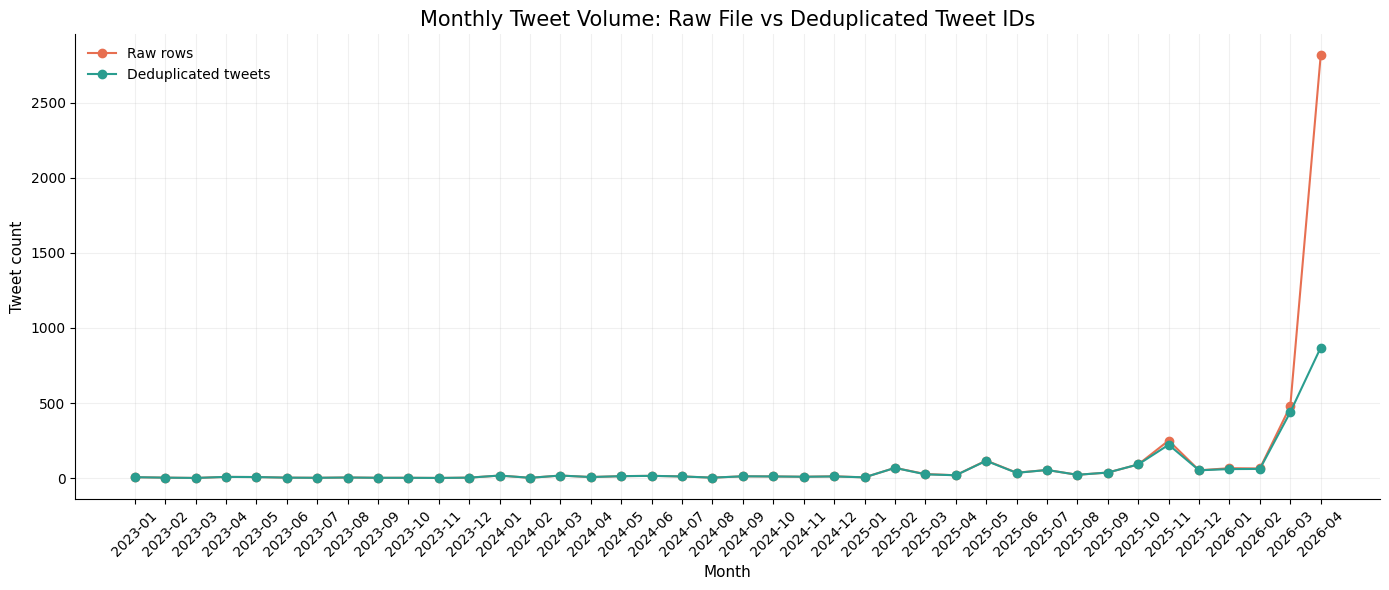

,Raw rows,Deduplicated tweets
month,,
2024-11,9,9
2024-12,12,11
2025-01,5,5
2025-02,68,68
2025-03,27,25
2025-04,19,19
2025-05,117,115
2025-06,36,35
2025-07,54,54


In [4]:
monthly_raw = tweets.groupby("month").size()
monthly_dedup = tweets_dedup.groupby("month").size()
month_index = monthly_raw.index.union(monthly_dedup.index)

monthly_compare = pd.DataFrame(
    {
        "Raw rows": monthly_raw.reindex(month_index, fill_value=0),
        "Deduplicated tweets": monthly_dedup.reindex(month_index, fill_value=0),
    }
)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_compare.index.astype(str), monthly_compare["Raw rows"], marker="o", color=RED, label="Raw rows")
ax.plot(
    monthly_compare.index.astype(str),
    monthly_compare["Deduplicated tweets"],
    marker="o",
    color=TEAL,
    label="Deduplicated tweets",
)
ax.set_title("Monthly Tweet Volume: Raw File vs Deduplicated Tweet IDs")
ax.set_xlabel("Month")
ax.set_ylabel("Tweet count")
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

display(monthly_compare.tail(18))


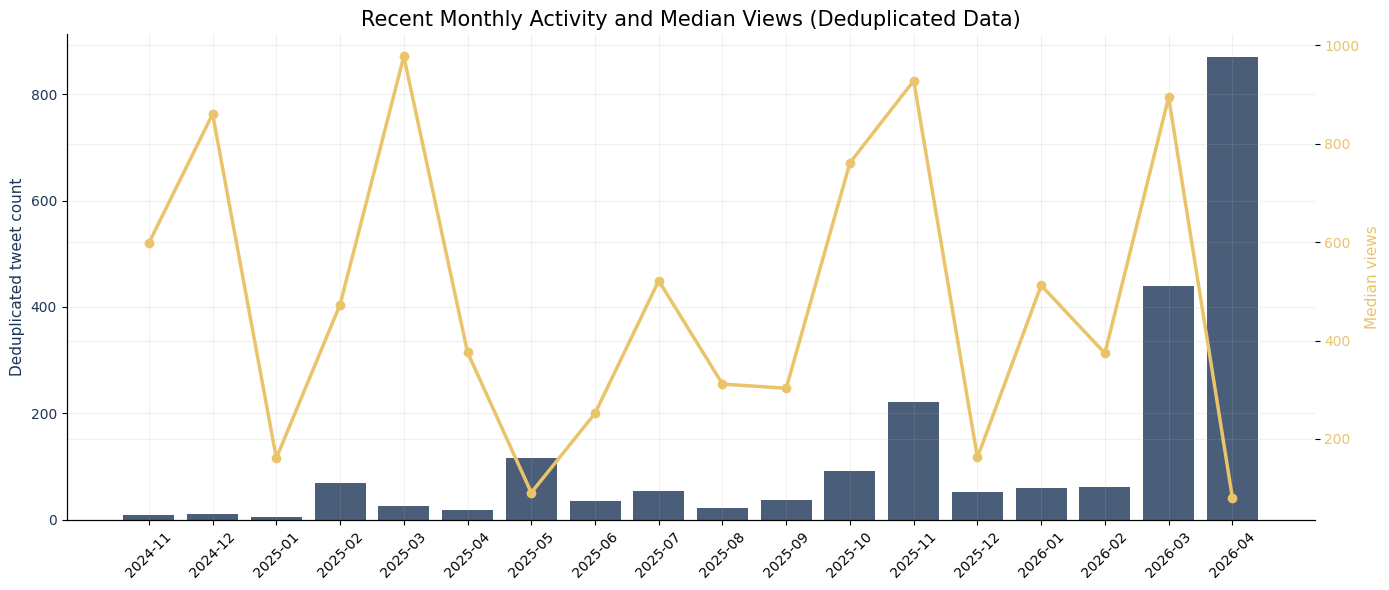

,posts,median_views,total_views,median_engagement
month,,,,
2024-11,9,598.000,12928,3.000
2024-12,11,860.000,22420,8.000
2025-01,5,161.000,39823,0.000
2025-02,68,473.000,37725103,2.500
2025-03,25,977.000,313578,10.000
2025-04,19,376.000,37882,3.000
2025-05,115,91.000,388799,1.000
2025-06,35,252.000,104683,2.000
2025-07,54,521.500,303017,1.500


In [5]:
monthly_activity = (
    tweets_dedup.groupby("month")
    .agg(
        posts=("id", "size"),
        median_views=("viewCount", "median"),
        total_views=("viewCount", "sum"),
        median_engagement=("engagement", "median"),
    )
    .tail(18)
)

fig, ax1 = plt.subplots(figsize=(14, 6))
months = monthly_activity.index.astype(str)
ax1.bar(months, monthly_activity["posts"], color=NAVY, alpha=0.8)
ax1.set_ylabel("Deduplicated tweet count", color=NAVY)
ax1.tick_params(axis="y", labelcolor=NAVY)
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(months, monthly_activity["median_views"], color=GOLD, marker="o", linewidth=2.5, label="Median views")
ax2.set_ylabel("Median views", color=GOLD)
ax2.tick_params(axis="y", labelcolor=GOLD)

ax1.set_title("Recent Monthly Activity and Median Views (Deduplicated Data)")
plt.tight_layout()
plt.show()

display(monthly_activity)


## Account Structure And Conversation Form

The context notes that the scrape includes politicians, FAA accounts, news outlets, and civilians. A simple handle-level view is helpful for seeing how concentrated the discussion is and whether the corpus behaves more like a broad public conversation or a relatively elite information network.


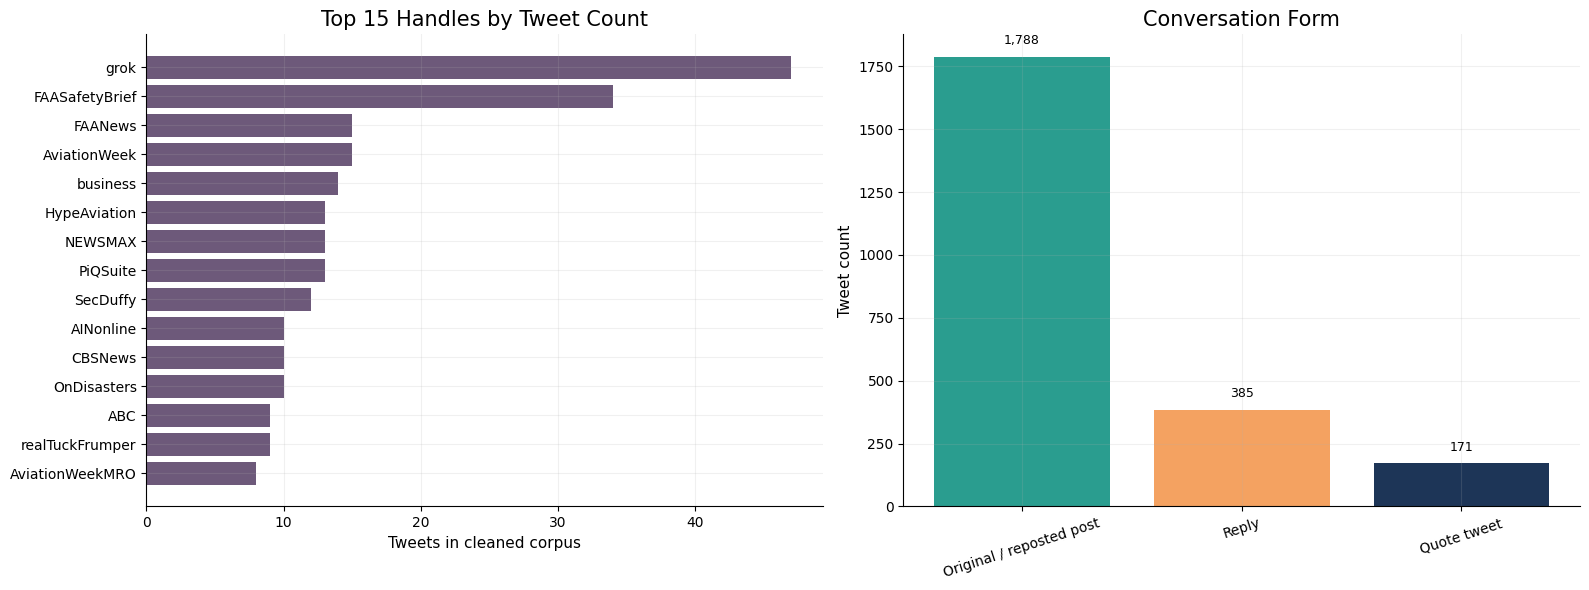

,handle,tweet_count
0,grok,47
1,FAASafetyBrief,34
2,FAANews,15
3,AviationWeek,15
4,business,14
5,HypeAviation,13
6,NEWSMAX,13
7,PiQSuite,13
8,SecDuffy,12
9,AINonline,10


,metric,value
0,share of tweets from top 5 handles,0.053
1,share of tweets from top 10 handles,0.079


In [6]:
top_handles = tweets_dedup["handle"].value_counts().head(15)
post_type_counts = tweets_dedup["post_type"].value_counts()
top_10_share = top_handles.head(10).sum() / len(tweets_dedup)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_handles.index[::-1], top_handles.values[::-1], color=PURPLE)
axes[0].set_title("Top 15 Handles by Tweet Count")
axes[0].set_xlabel("Tweets in cleaned corpus")

axes[1].bar(post_type_counts.index, post_type_counts.values, color=[TEAL, ORANGE, NAVY])
axes[1].set_title("Conversation Form")
axes[1].set_ylabel("Tweet count")
axes[1].tick_params(axis="x", rotation=18)
annotate_bars(axes[1])

plt.tight_layout()
plt.show()

concentration = pd.DataFrame(
    {
        "metric": ["share of tweets from top 5 handles", "share of tweets from top 10 handles"],
        "value": [
            top_handles.head(5).sum() / len(tweets_dedup),
            top_10_share,
        ],
    }
)

display(top_handles.rename_axis("handle").reset_index(name="tweet_count"))
display(concentration)


## Text Shape And Engagement

The proposal mentions stylistic markers such as emphasis and directness. Even before formal sentiment or emotion modeling, we can look at tweet length, use of mentions and hashtags, punctuation, and the skewness of reach metrics like views and engagement.


,mean,50%,75%,90%,95%,max
retweetCount,23.343,0.000,2.000,10.000,32.000,"20,129.000"
replyCount,11.550,0.000,1.000,6.000,18.000,"9,518.000"
likeCount,129.255,1.000,7.000,49.000,165.850,"89,943.000"
quoteCount,2.329,0.000,0.000,1.000,3.000,"2,618.000"
bookmarkCount,7.039,0.000,0.000,3.000,8.000,"4,394.000"
viewCount,"24,781.812",347.500,"1,834.500","10,834.600","32,647.700","36,077,130.000"
engagement,173.517,2.000,11.000,68.700,254.400,"126,602.000"
word_count,36.128,30.000,41.000,54.000,83.000,"1,282.000"
char_count,247.214,207.000,280.000,344.000,529.250,"7,347.000"
mention_count,0.351,0.000,0.000,1.000,2.000,12.000


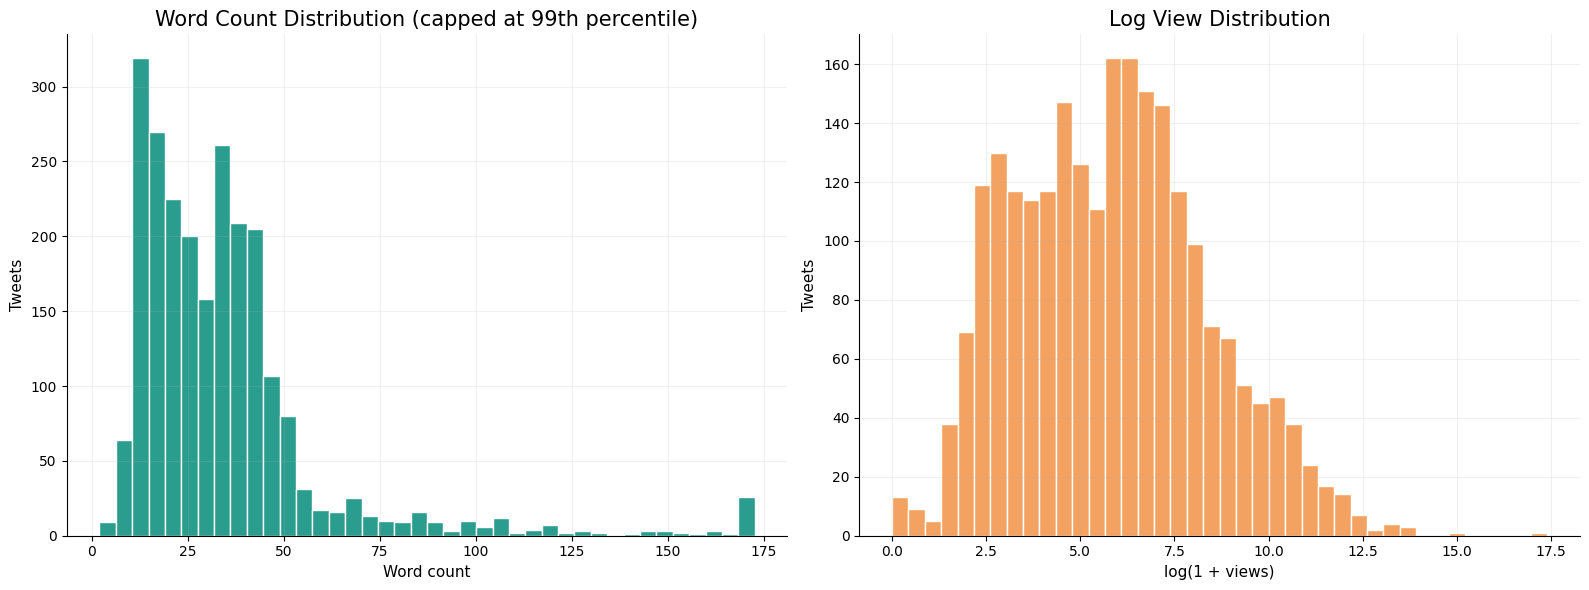

,feature,value
0,mean mentions per tweet,0.351
1,mean hashtags per tweet,0.466
2,mean URLs per tweet,0.781
3,mean exclamation marks per tweet,0.089
4,mean question marks per tweet,0.114
5,mean uppercase ratio,0.108


In [7]:
engagement_summary = tweets_dedup[
    [
        "retweetCount",
        "replyCount",
        "likeCount",
        "quoteCount",
        "bookmarkCount",
        "viewCount",
        "engagement",
        "word_count",
        "char_count",
        "mention_count",
        "hashtag_count",
        "url_count",
        "exclamation_count",
        "question_count",
        "uppercase_ratio",
    ]
].describe(percentiles=[0.5, 0.75, 0.9, 0.95]).T

display(engagement_summary[["mean", "50%", "75%", "90%", "95%", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

word_cap = tweets_dedup["word_count"].quantile(0.99)
axes[0].hist(
    tweets_dedup["word_count"].clip(upper=word_cap),
    bins=40,
    color=TEAL,
    edgecolor="white",
)
axes[0].set_title("Word Count Distribution (capped at 99th percentile)")
axes[0].set_xlabel("Word count")
axes[0].set_ylabel("Tweets")

axes[1].hist(
    tweets_dedup["log_views"],
    bins=40,
    color=ORANGE,
    edgecolor="white",
)
axes[1].set_title("Log View Distribution")
axes[1].set_xlabel("log(1 + views)")
axes[1].set_ylabel("Tweets")

plt.tight_layout()
plt.show()

style_features = pd.DataFrame(
    {
        "feature": [
            "mean mentions per tweet",
            "mean hashtags per tweet",
            "mean URLs per tweet",
            "mean exclamation marks per tweet",
            "mean question marks per tweet",
            "mean uppercase ratio",
        ],
        "value": [
            tweets_dedup["mention_count"].mean(),
            tweets_dedup["hashtag_count"].mean(),
            tweets_dedup["url_count"].mean(),
            tweets_dedup["exclamation_count"].mean(),
            tweets_dedup["question_count"].mean(),
            tweets_dedup["uppercase_ratio"].mean(),
        ],
    }
)
display(style_features)


## Policy Theme Tagging

Because the provided CSV does not include sentiment or complaint labels, a useful EDA compromise is to tag tweets with transparent keyword-based themes that mirror the project framing. These are not final labels, but they quickly show what the discourse is about and which themes attract more attention.


,theme,tweet_count,share_of_cleaned_tweets
0,Air traffic control,1358,0.579
4,FAA policy and oversight,1154,0.492
2,Safety and incidents,974,0.416
1,Staffing and hiring,673,0.287
3,Delays and disruptions,365,0.156
5,Modernization and technology,340,0.145


,theme,median_views,mean_views,median_engagement,mean_engagement
3,Delays and disruptions,556.000,"7,613.685",3.000,67.759
2,Safety and incidents,541.000,"48,287.766",2.000,251.012
1,Staffing and hiring,440.000,"64,671.673",2.000,377.967
4,FAA policy and oversight,347.500,"39,702.881",1.000,206.017
0,Air traffic control,226.500,"36,632.213",2.000,244.415
5,Modernization and technology,217.000,"112,859.112",2.000,553.488


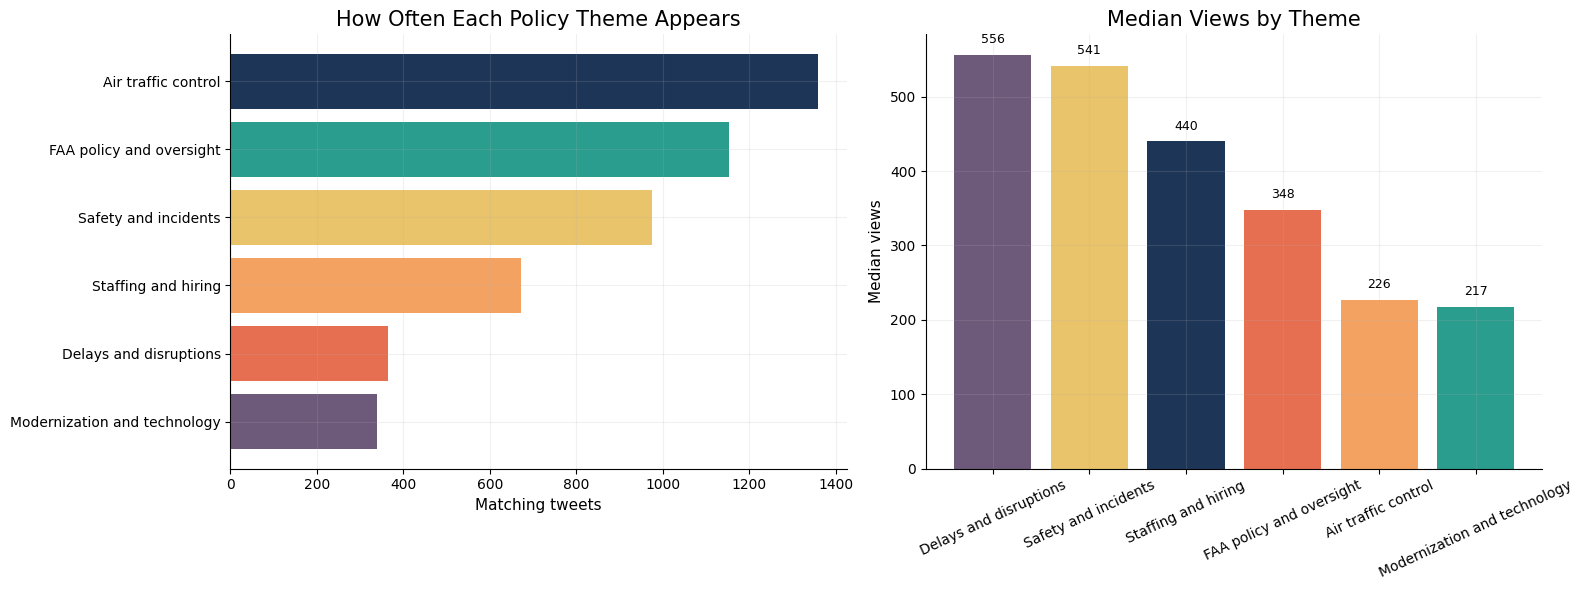

In [8]:
theme_cols = list(THEME_LABELS.keys())

theme_counts = pd.DataFrame(
    {
        "theme": [THEME_LABELS[col] for col in theme_cols],
        "tweet_count": [int(tweets_dedup[col].sum()) for col in theme_cols],
        "share_of_cleaned_tweets": [tweets_dedup[col].mean() for col in theme_cols],
    }
).sort_values("tweet_count", ascending=False)

theme_engagement = []
for col in theme_cols:
    subset = tweets_dedup[tweets_dedup[col]]
    theme_engagement.append(
        {
            "theme": THEME_LABELS[col],
            "median_views": subset["viewCount"].median(),
            "mean_views": subset["viewCount"].mean(),
            "median_engagement": subset["engagement"].median(),
            "mean_engagement": subset["engagement"].mean(),
        }
    )
theme_engagement = pd.DataFrame(theme_engagement).sort_values("median_views", ascending=False)

display(theme_counts)
display(theme_engagement)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    theme_counts["theme"][::-1],
    theme_counts["tweet_count"][::-1],
    color=[NAVY, TEAL, GOLD, ORANGE, RED, PURPLE][::-1],
)
axes[0].set_title("How Often Each Policy Theme Appears")
axes[0].set_xlabel("Matching tweets")

axes[1].bar(
    theme_engagement["theme"],
    theme_engagement["median_views"],
    color=[PURPLE, GOLD, NAVY, RED, ORANGE, TEAL],
)
axes[1].set_title("Median Views by Theme")
axes[1].set_ylabel("Median views")
axes[1].tick_params(axis="x", rotation=25)
annotate_bars(axes[1], fmt="{:,.0f}")

plt.tight_layout()
plt.show()


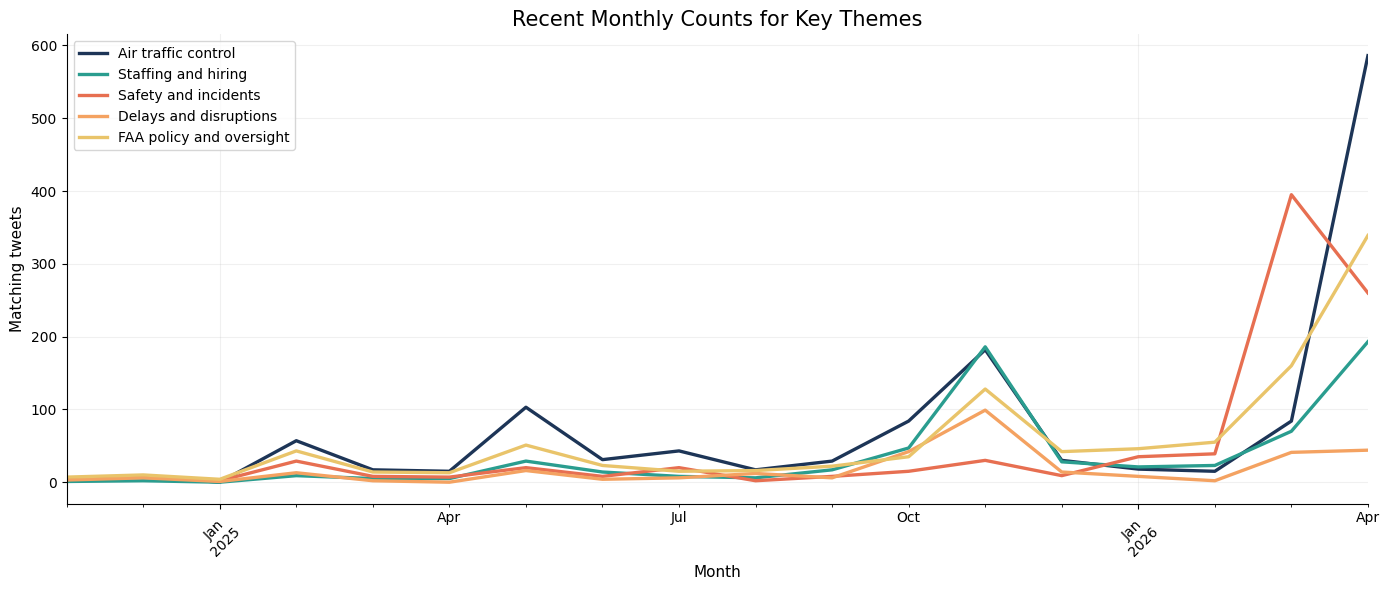

,Air traffic control,Staffing and hiring,Safety and incidents,Delays and disruptions,FAA policy and oversight
month,,,,,
2024-11,3,1,4,3,7
2024-12,8,2,9,6,10
2025-01,0,0,2,1,4
2025-02,57,9,29,13,43
2025-03,17,5,8,2,14
2025-04,15,5,7,0,13
2025-05,103,29,20,16,51
2025-06,31,14,8,4,23
2025-07,43,8,20,6,15


In [9]:
selected_theme_cols = [
    "theme_air_traffic_control",
    "theme_staffing_hiring",
    "theme_safety_incidents",
    "theme_delays_disruptions",
    "theme_faa_policy_oversight",
]

theme_monthly = tweets_dedup.groupby("month")[selected_theme_cols].sum().tail(18)
theme_monthly.columns = [THEME_LABELS[col] for col in selected_theme_cols]

theme_monthly.plot(figsize=(14, 6), linewidth=2.4, color=[NAVY, TEAL, RED, ORANGE, GOLD])
plt.title("Recent Monthly Counts for Key Themes")
plt.xlabel("Month")
plt.ylabel("Matching tweets")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(theme_monthly)


,Air traffic control,Staffing and hiring,Safety and incidents,Delays and disruptions,FAA policy and oversight,Modernization and technology
Air traffic control,1358,562,234,209,520,237
Staffing and hiring,562,673,131,178,381,69
Safety and incidents,234,131,974,167,567,158
Delays and disruptions,209,178,167,365,246,37
FAA policy and oversight,520,381,567,246,1154,172
Modernization and technology,237,69,158,37,172,340


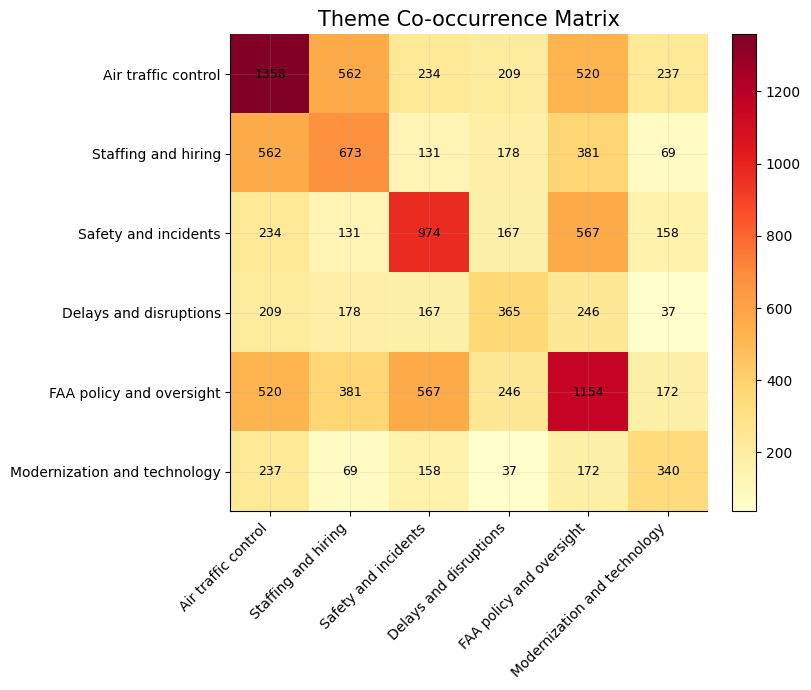

In [10]:
theme_matrix = tweets_dedup[theme_cols].astype(int)
cooccurrence = theme_matrix.T.dot(theme_matrix)
cooccurrence.index = [THEME_LABELS[col] for col in cooccurrence.index]
cooccurrence.columns = [THEME_LABELS[col] for col in cooccurrence.columns]

display(cooccurrence)

fig, ax = plt.subplots(figsize=(8.5, 7))
image = ax.imshow(cooccurrence.values, cmap="YlOrRd")
ax.set_xticks(range(len(cooccurrence.columns)))
ax.set_xticklabels(cooccurrence.columns, rotation=45, ha="right")
ax.set_yticks(range(len(cooccurrence.index)))
ax.set_yticklabels(cooccurrence.index)
ax.set_title("Theme Co-occurrence Matrix")

for i in range(cooccurrence.shape[0]):
    for j in range(cooccurrence.shape[1]):
        ax.text(j, i, int(cooccurrence.iloc[i, j]), ha="center", va="center", fontsize=9)

plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Language Patterns

The proposal planned to inspect n-grams and recurring complaint language. The simple counts below give a first pass at that idea without introducing a heavier NLP dependency stack.


In [11]:
overall_words = pd.DataFrame(top_ngrams(tweets_dedup["text"], ngram=1, top_n=20), columns=["term", "count"])
overall_bigrams = pd.DataFrame(top_ngrams(tweets_dedup["text"], ngram=2, top_n=20), columns=["term", "count"])

staffing_words = pd.DataFrame(
    top_ngrams(
        tweets_dedup.loc[tweets_dedup["theme_staffing_hiring"], "text"],
        ngram=1,
        top_n=15,
        extra_stopwords={"air", "traffic", "control", "faa"},
    ),
    columns=["term", "count"],
)
safety_words = pd.DataFrame(
    top_ngrams(
        tweets_dedup.loc[tweets_dedup["theme_safety_incidents"], "text"],
        ngram=1,
        top_n=15,
        extra_stopwords={"air", "traffic", "control", "faa"},
    ),
    columns=["term", "count"],
)

display(overall_words)
display(overall_bigrams)
display(staffing_words.rename(columns={"count": "staffing_count"}))
display(safety_words.rename(columns={"count": "safety_count"}))


,term,count
0,air,1823
1,traffic,1531
2,control,1237
3,faa,1101
4,safety,716
5,aviation,495
6,staffing,383
7,airport,376
8,laguardia,367
9,flight,322


,term,count
0,air traffic,1482
1,traffic control,1156
2,air canada,191
3,federal aviation,163
4,aviation administration,162
5,traffic controllers,155
6,control staffing,142
7,traffic controller,131
8,aviation safety,127
9,laguardia airport,123


,term,staffing_count
0,staffing,383
1,shortage,241
2,controllers,169
3,controller,165
4,safety,128
5,shortages,125
6,delays,123
7,flight,121
8,aviation,117
9,shutdown,117


,term,safety_count
0,safety,716
1,laguardia,365
2,aviation,315
3,crash,254
4,airport,252
5,collision,214
6,canada,211
7,flight,191
8,runway,191
9,delays,169


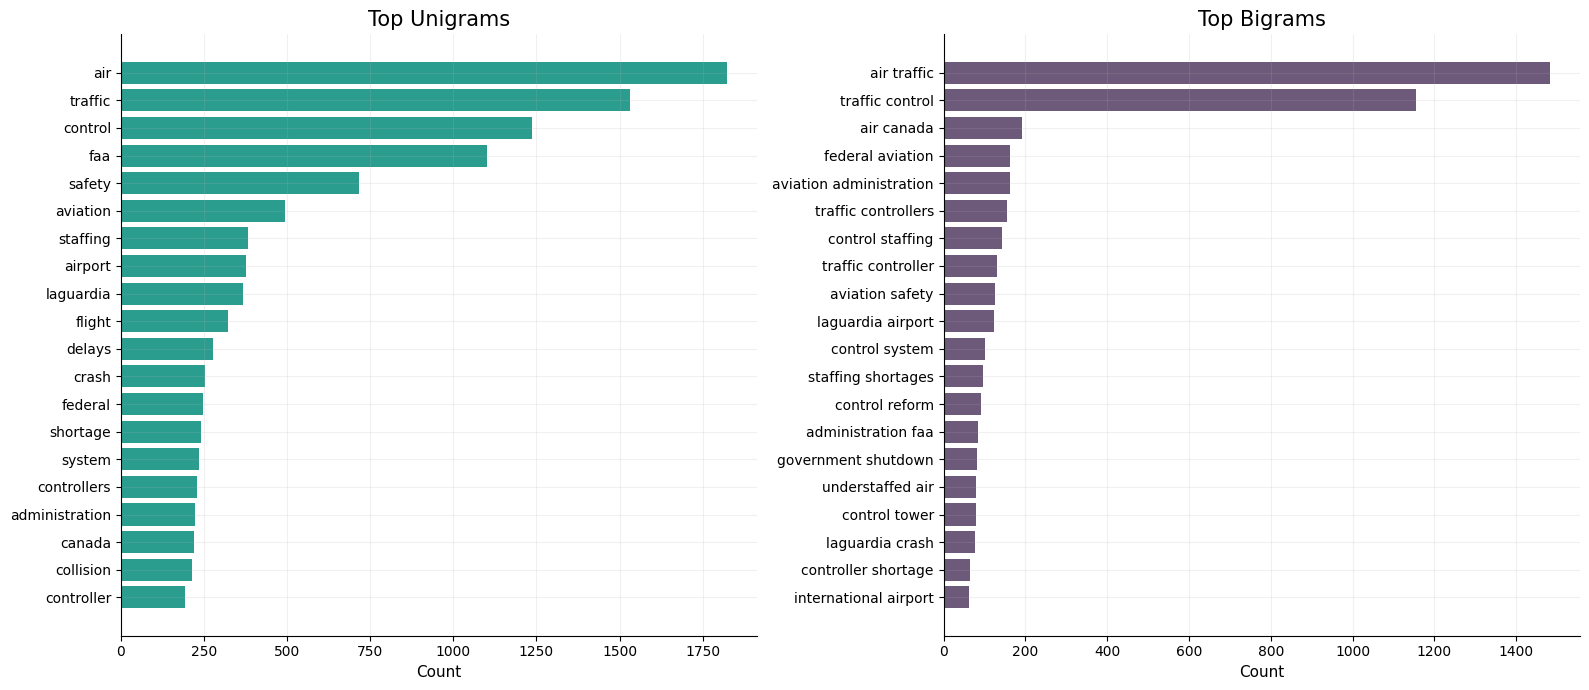

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(overall_words["term"][::-1], overall_words["count"][::-1], color=TEAL)
axes[0].set_title("Top Unigrams")
axes[0].set_xlabel("Count")

axes[1].barh(overall_bigrams["term"][::-1], overall_bigrams["count"][::-1], color=PURPLE)
axes[1].set_title("Top Bigrams")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()


## High-Engagement Examples

Looking at the most-engaged posts is useful because a policy conversation can be shaped by a relatively small number of highly visible tweets. The table below is not for qualitative coding yet, but it does surface what kinds of posts received disproportionate reach.


In [13]:
top_posts = (
    tweets_dedup.sort_values(["engagement", "viewCount"], ascending=False)
    .loc[
        :,
        [
            "created_at_est",
            "handle",
            "engagement",
            "viewCount",
            "retweetCount",
            "replyCount",
            "likeCount",
            "text",
        ],
    ]
    .head(15)
    .copy()
)
top_posts["text"] = top_posts["text"].str.replace(r"\s+", " ", regex=True).str.slice(0, 220).add("...")
display(top_posts)


,created_at_est,handle,engagement,viewCount,retweetCount,replyCount,likeCount,text
219,2025-02-17 20:12:17-05:00,SecDuffy,126602,36077130,20129,9518,89943,"Mayor Pete failed for four years to address the air traffic controller shortage and upgrade our outdated, World War II-era air traffic control system. In less than four weeks, we have already begun the process and are en..."
217,2025-02-17 16:46:27-05:00,EricLDaugh,14584,728845,1278,4135,8498,"NBC REPORTER ON PLANE CRASH: There has been talk about staff cuts at the FAA as a part of President Trump's effort to trim down the federal workforce. The FAA has been complaining for years that they are understaffed, es..."
1725,2026-04-10 10:31:09-04:00,SecDuffy,14467,3197424,1000,630,9528,"🚨👀 Watch this… YOU can be the future of air traffic control It’s not a GAME, its a CAREER Applications open April 17th at Midnight @FAANews https://t.co/JVpgCIeF58..."
1588,2026-04-07 15:38:32-04:00,SecDuffy,14327,123348,1832,320,12078,"Thanks to President Trump, we’re surging air traffic controller hiring like never before. Staffing levels are at a SIX YEAR HIGH, with more and more coming through the pipeline. 📺 My interview with @PowerLunch👇 https://t..."
1277,2026-03-27 17:37:05-04:00,FurkanGozukara,12811,606497,1804,209,10056,Incredible heroism revealed. An aviation expert explains how the pilots in the LaGuardia crash intentionally took the impact head on. They refused to veer away to prevent the fuel filled wings from hitting the truck &amp...
253,2025-03-10 17:44:28-04:00,RCamposDuffy,11479,151809,1238,221,9920,Never seen my husband more committed to fixing a problem as he is to fixing America’s air traffic control system &amp; shortage. 👇🏼...
2101,2026-04-11 16:14:44-04:00,dpoddolphinpro,10919,279463,577,17,9922,"Ellington Field Air Traffic Control welcomes the Artemis II crew back to Houston Ellington Tower: ""Do you have your Artemis passengers onboard?"" NASA5: ""We do."" Ellington: ""NASA5, tell Artemis welcome back, and we're rea..."
2222,2026-04-12 18:39:04-04:00,xbradtc,10093,212616,328,123,9368,The FAA wants to hire gamers to fill air traffic control jobs. The planes will land safely but the pilots are going to get called a bunch of slurs on the way down....
1096,2026-03-23 04:10:36-04:00,juliamacfarlane,9576,938463,1809,503,6979,"If FAA staffing shortages turn out to be a key aspect of this horrible tragedy, remember that @elonmusk and his “Doge” department fired hundreds of FAA staffers last year - including safety workers, and even tried to fir..."
1591,2026-04-07 16:13:23-04:00,SecDuffy,9037,147959,1443,180,7267,We are working at the Speed of Trump to build our new air traffic control system 🇺🇸 Thanks to $12.5 BILLION into BRAND-NEW equipment at airports across the country: ✔️ State of the Art Radars ✔️ Electronic Flight Strips ...


## EDA Takeaways

The code cell below turns the audit into a few concise bullets you can reuse in your write-up or presentation notes.


In [14]:
top_theme = theme_counts.iloc[0]["theme"]
top_10_handle_share = tweets_dedup["handle"].value_counts().head(10).sum() / len(tweets_dedup)
max_row = tweets_dedup.sort_values("engagement", ascending=False).iloc[0]

summary_points = [
    f"Deduplicating by tweet ID reduces the file from {len(tweets):,} rows to {len(tweets_dedup):,} unique tweets, removing {1 - len(tweets_dedup) / len(tweets):.1%} duplicated records.",
    f"The cleaned corpus spans {tweets_dedup['created_at_est'].min().date()} to {tweets_dedup['created_at_est'].max().date()} in Eastern Time, which is broader than the January 2025-to-present scrape window described in the email context and should be acknowledged in the write-up.",
    f"The most common transparent keyword theme is {top_theme}, confirming that this corpus centers heavily on operational FAA and air-traffic-control discourse rather than consumer airline service complaints alone.",
    f"Conversation is concentrated: the top 10 handles account for {top_10_handle_share:.1%} of cleaned tweets.",
    f"Reach is extremely skewed: median combined engagement is {tweets_dedup['engagement'].median():,.0f}, while the maximum is {tweets_dedup['engagement'].max():,.0f} from @{max_row['handle']}.",
]

for point in summary_points:
    print(f"- {point}")


- Deduplicating by tweet ID reduces the file from 4,372 rows to 2,344 unique tweets, removing 46.4% duplicated records.
- The cleaned corpus spans 2023-01-11 to 2026-04-13 in Eastern Time, which is broader than the January 2025-to-present scrape window described in the email context and should be acknowledged in the write-up.
- The most common transparent keyword theme is Air traffic control, confirming that this corpus centers heavily on operational FAA and air-traffic-control discourse rather than consumer airline service complaints alone.
- Conversation is concentrated: the top 10 handles account for 7.9% of cleaned tweets.
- Reach is extremely skewed: median combined engagement is 2, while the maximum is 126,602 from @SecDuffy.


## Next Steps Aligned With The Proposal

This EDA sets up several natural next steps that would match the proposal more closely:

1. Add a sentiment or emotion layer to the cleaned tweets, but frame it as descriptive enrichment rather than ground truth.
2. Separate actor types more explicitly, for example official government accounts, journalists, politicians, industry accounts, and general-public users.
3. Build topic models or embedding-based clusters on the deduplicated text to identify recurring complaint or policy frames.
4. If you still want the original comparison angle, run a parallel notebook on the 2015 airline-sentiment Kaggle data and compare how language around aviation harms differs across the two corpora.
